# [Synthesis] KAN-TabNet Interpretability & Visuals | Poker Hand

### Setup

In [1]:
import os
import sys
import json
import zipfile
import shutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

In [2]:
if 'google.colab' in str(get_ipython()):
    from google.colab import userdata
    REPO_OWNER = "chuo-v"
    REPO_NAME = "kan-tabnet-experiments"

    if not os.path.exists(REPO_NAME):
        try:
            token = userdata.get('GITHUB_TOKEN')
            repo_url = f"https://{token}@github.com/{REPO_OWNER}/{REPO_NAME}.git"
            print("Cloning private repository via PAT...")
        except userdata.SecretNotFoundError:
            repo_url = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
            print("Cloning public repository...")

        !git clone {repo_url}

    os.chdir(f"/content/{REPO_NAME}/notebooks/poker_hand")
    sys.path.append("../../")

print(f"Working Directory Ready: {os.getcwd()}")

Cloning private repository via PAT...
Cloning into 'kan-tabnet-experiments'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 168 (delta 60), reused 80 (delta 46), pack-reused 64 (from 2)
Receiving objects: 100% (168/168), 22.74 MiB | 30.88 MiB/s, done.
Resolving deltas: 100% (63/63), done.
Working Directory Ready: /content/kan-tabnet-experiments/notebooks/poker_hand


In [3]:
# global plotting style
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# directories
DATASET_NAME = 'poker_hand'
TABLES_DIR = f'../../results/{DATASET_NAME}/tables'
FIGURES_DIR = f'../../results/{DATASET_NAME}/figures'
MODELS_DIR = f'../../results/{DATASET_NAME}/models'
os.makedirs(FIGURES_DIR, exist_ok=True)

# load all metrics
files = {
    'Vanilla StepLR': '01_vanilla_baseline_step_lr_metrics.json',
    'KAN StepLR (Base)': '02_kan_param_matched_step_lr_metrics.json',
    'Vanilla CosineLR': '03_vanilla_baseline_cosine_lr_metrics.json',
    'KAN CosineLR': '04_kan_param_matched_cosine_lr_metrics.json',
    'KAN 5x5': '05_kan_sensitivity_5x5_metrics.json',
    'KAN 7x3 (Decision Heavy)': '06_kan_sensitivity_7x3_metrics.json',
    'KAN LR=0.0025 (Champion)': '07_kan_sensitivity_lr_0025_metrics.json'
}

metrics = {}
for name, filename in files.items():
    filepath = os.path.join(TABLES_DIR, filename)
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            metrics[name] = json.load(f)

print(f"Successfully loaded {len(metrics)} experiment logs.")

Successfully loaded 7 experiment logs.


### Validation Accuracy (EMA Smoothed)

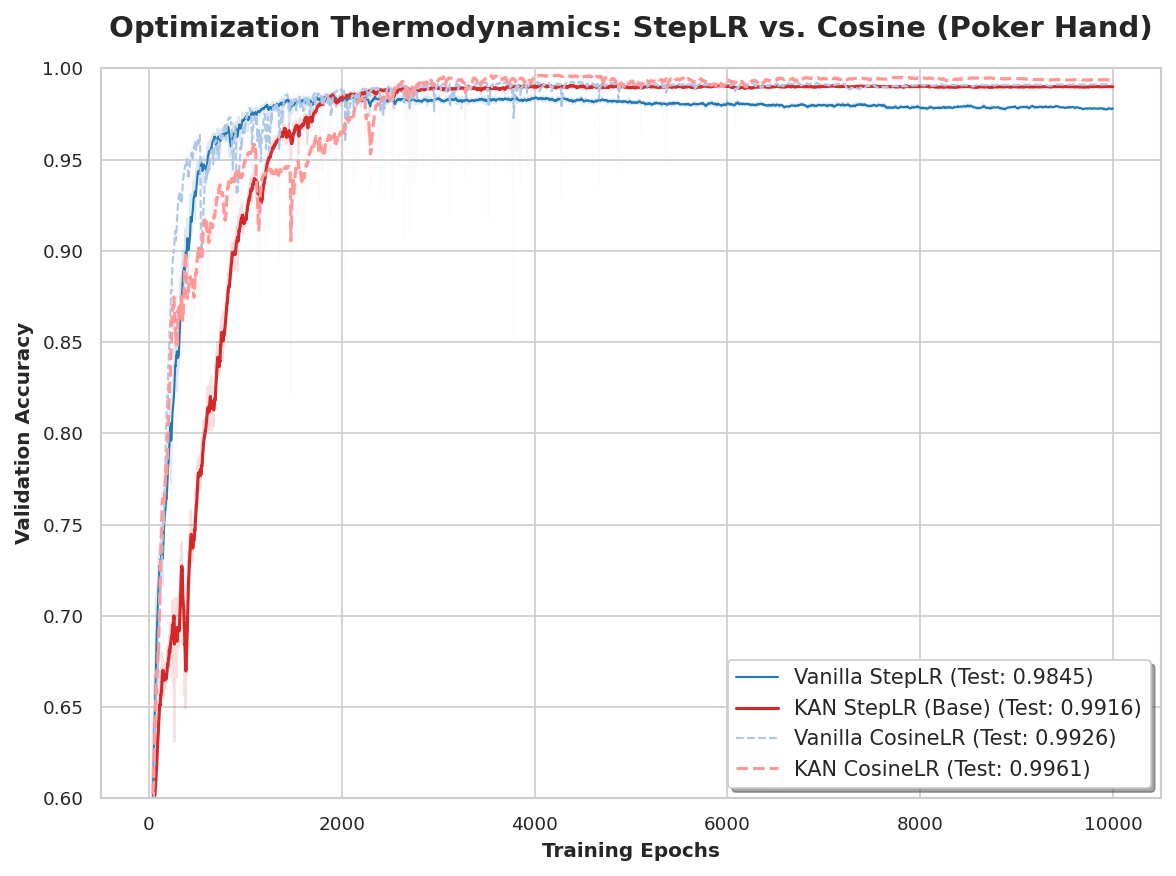

In [4]:
plt.figure(figsize=(8, 6))
ema_span = 20

colors = {'Vanilla StepLR': '#1f77b4', 'KAN StepLR (Base)': '#d62728',
          'Vanilla CosineLR': '#aec7e8', 'KAN CosineLR': '#ff9896'}

for name in ['Vanilla StepLR', 'KAN StepLR (Base)', 'Vanilla CosineLR', 'KAN CosineLR']:
    if name in metrics:
        history = metrics[name]['training_history']
        val_acc = history.get('valid_accuracy', history.get('val_0_accuracy', []))

        # calculate EMA
        val_ema = pd.Series(val_acc).ewm(span=ema_span, adjust=False).mean()

        linestyle = '-' if 'StepLR' in name else '--'
        linewidth = 1.5 if 'KAN' in name else 1
        alpha_raw = 0.15 if 'StepLR' in name else 0.05

        # plot raw (faint) and EMA (bold)
        plt.plot(val_acc, color=colors[name], linewidth=1, alpha=alpha_raw)
        plt.plot(val_ema, label=f"{name} (Test: {metrics[name]['final_test_accuracy']:.4f})",
                 color=colors[name], linewidth=linewidth, linestyle=linestyle)

plt.title('Optimization Thermodynamics: StepLR vs. Cosine (Poker Hand)', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Training Epochs', fontweight='bold')
plt.ylabel('Validation Accuracy', fontweight='bold')
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_thermodynamics_ema.png', dpi=300, bbox_inches='tight')
plt.show()

### Architectural Topology

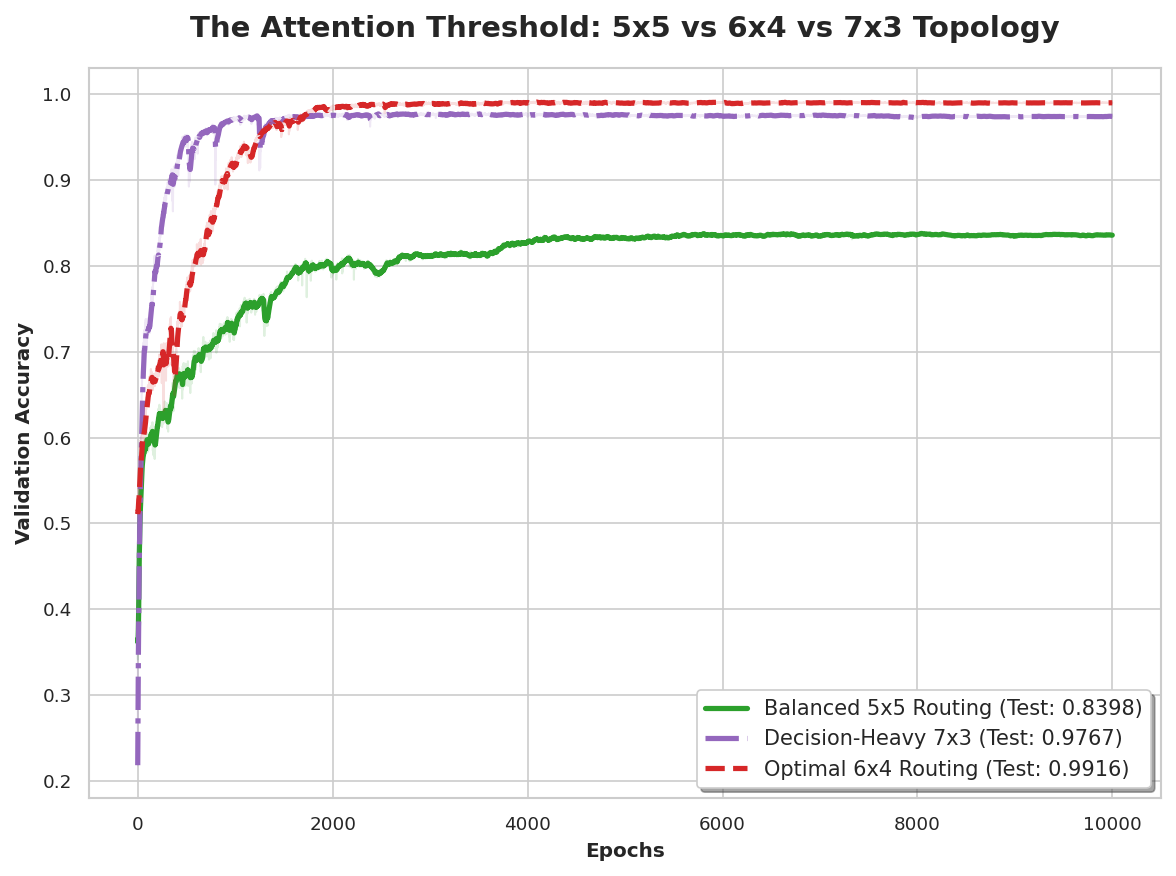

In [5]:
if all(m in metrics for m in ['KAN StepLR (Base)', 'KAN 5x5', 'KAN 7x3 (Decision Heavy)']):
    plt.figure(figsize=(8, 6))

    # 5x5 Balanced Routing
    bal_acc = metrics['KAN 5x5']['training_history'].get('valid_accuracy', [])
    bal_ema = pd.Series(bal_acc).ewm(span=ema_span, adjust=False).mean()
    plt.plot(bal_acc, color='#2ca02c', linewidth=1, alpha=0.15)
    plt.plot(bal_ema, label=f"Balanced 5x5 Routing (Test: {metrics['KAN 5x5']['final_test_accuracy']:.4f})",
             color='#2ca02c', linewidth=2.5)

    # 7x3 Decision Heavy
    dec_acc = metrics['KAN 7x3 (Decision Heavy)']['training_history'].get('valid_accuracy', [])
    dec_ema = pd.Series(dec_acc).ewm(span=ema_span, adjust=False).mean()
    plt.plot(dec_acc, color='#9467bd', linewidth=1, alpha=0.15)
    plt.plot(dec_ema, label=f"Decision-Heavy 7x3 (Test: {metrics['KAN 7x3 (Decision Heavy)']['final_test_accuracy']:.4f})",
             color='#9467bd', linewidth=2.5, linestyle='-.')

    # 6x4 Optimal Routing (The Champion)
    opt_acc = metrics['KAN StepLR (Base)']['training_history'].get('valid_accuracy', [])
    opt_ema = pd.Series(opt_acc).ewm(span=ema_span, adjust=False).mean()
    plt.plot(opt_acc, color='#d62728', linewidth=1, alpha=0.15)
    plt.plot(opt_ema, label=f"Optimal 6x4 Routing (Test: {metrics['KAN StepLR (Base)']['final_test_accuracy']:.4f})",
             color='#d62728', linewidth=2.5, linestyle='--')

    plt.title('The Attention Threshold: 5x5 vs 6x4 vs 7x3 Topology', pad=15, fontweight='bold', fontsize=14)
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel('Validation Accuracy', fontweight='bold')
    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/02_topology_combinatorial.png', dpi=300, bbox_inches='tight')
    plt.show()

### Thermodynamic Control (Learning Rate Sensitivity)

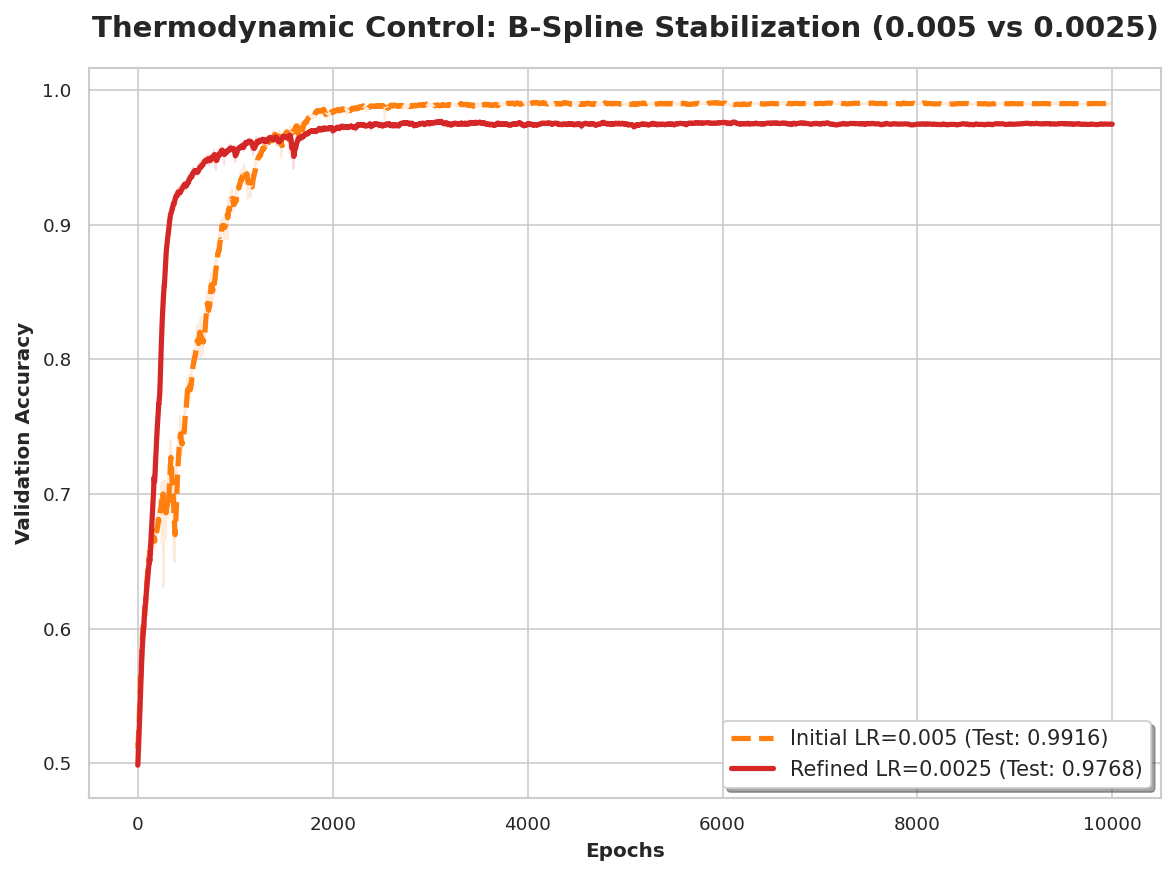

In [6]:
if 'KAN StepLR (Base)' in metrics and 'KAN LR=0.0025 (Champion)' in metrics:
    plt.figure(figsize=(8, 6))

    base_acc = metrics['KAN StepLR (Base)']['training_history'].get('valid_accuracy', [])
    champ_acc = metrics['KAN LR=0.0025 (Champion)']['training_history'].get('valid_accuracy', [])

    base_ema = pd.Series(base_acc).ewm(span=ema_span, adjust=False).mean()
    champ_ema = pd.Series(champ_acc).ewm(span=ema_span, adjust=False).mean()

    plt.plot(base_acc, color='#ff7f0e', linewidth=1, alpha=0.15)
    plt.plot(base_ema, label=f"Initial LR=0.005 (Test: {metrics['KAN StepLR (Base)']['final_test_accuracy']:.4f})",
             color='#ff7f0e', linewidth=2.5, linestyle='--')

    plt.plot(champ_acc, color='#d62728', linewidth=1, alpha=0.15)
    plt.plot(champ_ema, label=f"Refined LR=0.0025 (Test: {metrics['KAN LR=0.0025 (Champion)']['final_test_accuracy']:.4f})",
             color='#d62728', linewidth=2.5)

    plt.title('Thermodynamic Control: B-Spline Stabilization (0.005 vs 0.0025)', pad=15, fontweight='bold', fontsize=14)
    plt.xlabel('Epochs', fontweight='bold')
    plt.ylabel('Validation Accuracy', fontweight='bold')
    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/03_thermodynamic_control.png', dpi=300, bbox_inches='tight')
    plt.show()

### The Pareto Frontier (Parameters vs. Accuracy)

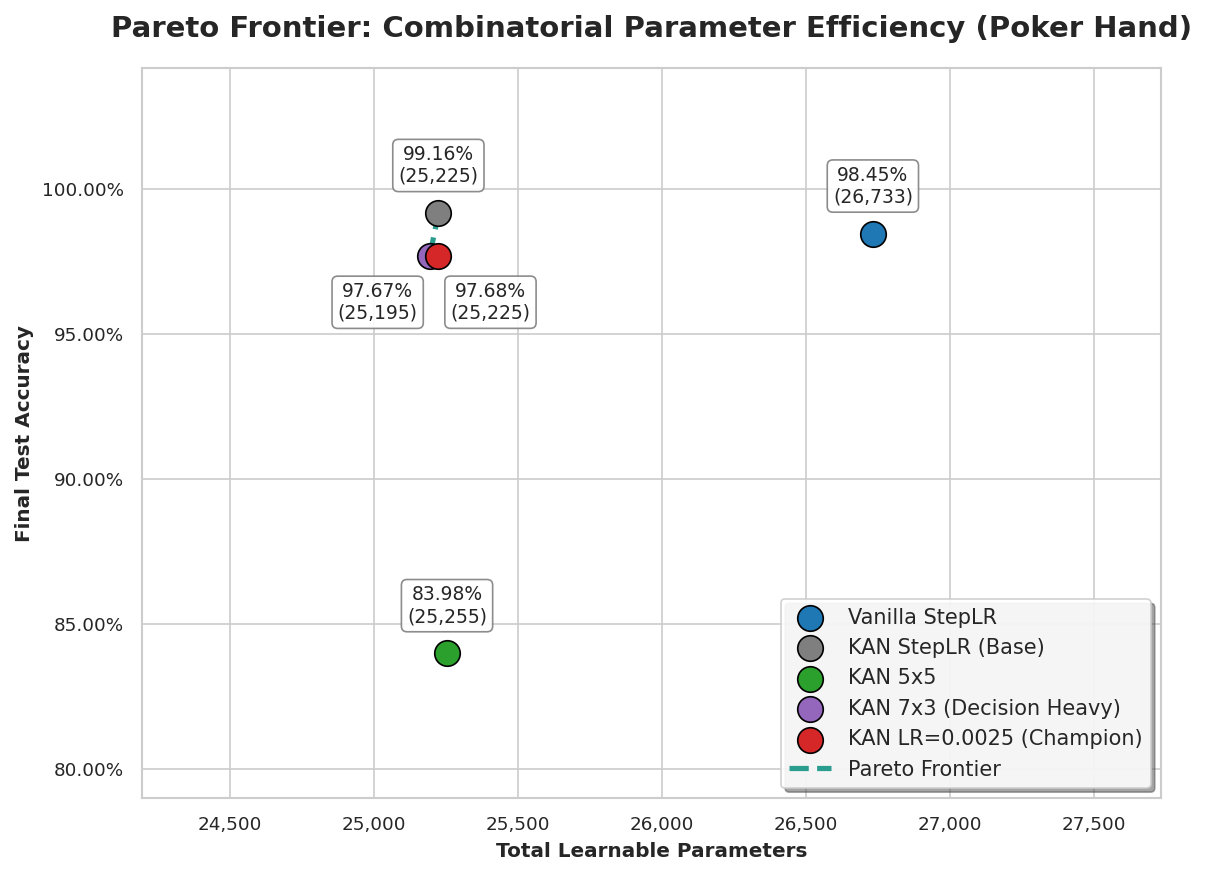

In [7]:
models_to_plot = ['Vanilla StepLR', 'KAN StepLR (Base)', 'KAN 5x5', 'KAN 7x3 (Decision Heavy)', 'KAN LR=0.0025 (Champion)']
colors = ['#1f77b4', '#7f7f7f', '#2ca02c', '#9467bd', '#d62728']

plt.figure(figsize=(8, 6))

plotted_params = []
plotted_accs = []

# specific (x, y) offsets for each model to prevent overlapping
custom_offsets = {
    'Vanilla StepLR': (0, 15),
    'KAN StepLR (Base)': (0, 15),
    'KAN 5x5': (0, 15),
    'KAN 7x3 (Decision Heavy)': (-25, -30),
    'KAN LR=0.0025 (Champion)': (25, -30)
}

for idx, model in enumerate(models_to_plot):
    if model in metrics:
        param = metrics[model]['parameters']
        acc = metrics[model]['final_test_accuracy']
        plotted_params.append(param)
        plotted_accs.append(acc)

        plt.scatter(param, acc, label=model, color=colors[idx], s=150, edgecolor='black', zorder=5)

        offset = custom_offsets.get(model, (0, 15))

        plt.annotate(
            f'{acc*100:.2f}%\n({param:,})', (param, acc),
            textcoords="offset points", xytext=offset, ha='center',
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            zorder=6
        )

# dynamically calculate the Pareto frontier
all_models = []
for name in models_to_plot:
    if name in metrics:
        all_models.append((metrics[name]['parameters'], metrics[name]['final_test_accuracy']))
# sort primarily by parameters (ascending), then by accuracy (descending) to break ties
all_models.sort(key=lambda x: (x[0], -x[1]))
fx = []
fy = []
current_max_acc = -1
# keep only models that set a new high-score for accuracy
for params, acc in all_models:
    if acc > current_max_acc:
        fx.append(params)
        fy.append(acc)
        current_max_acc = acc
if len(fx) > 1:
    plt.plot(fx, fy, color='#2a9d8f', linestyle='--', linewidth=2.5, label='Pareto Frontier', zorder=4)

plt.title('Pareto Frontier: Combinatorial Parameter Efficiency (Poker Hand)', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Total Learnable Parameters', fontweight='bold')
plt.ylabel('Final Test Accuracy', fontweight='bold')

if plotted_accs and plotted_params:
    plt.ylim(min(plotted_accs) - 0.05, max(plotted_accs) + 0.05)
    x_range = max(plotted_params) - min(plotted_params)
    plt.xlim(min(plotted_params) - max(1000, x_range * 0.5), max(plotted_params) + max(1000, x_range * 0.5))

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y*100:.2f}%'))
plt.legend(loc='lower right', fontsize=10, framealpha=0.9, shadow=True)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_pareto_frontier.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretability - Extracting the B-Splines (Combinatorial Rules)

Extracted B-Spline Tensor Shape: (20, 10, 8)
Output Neurons: 20 | Input Features: 10 | Control Points: 8



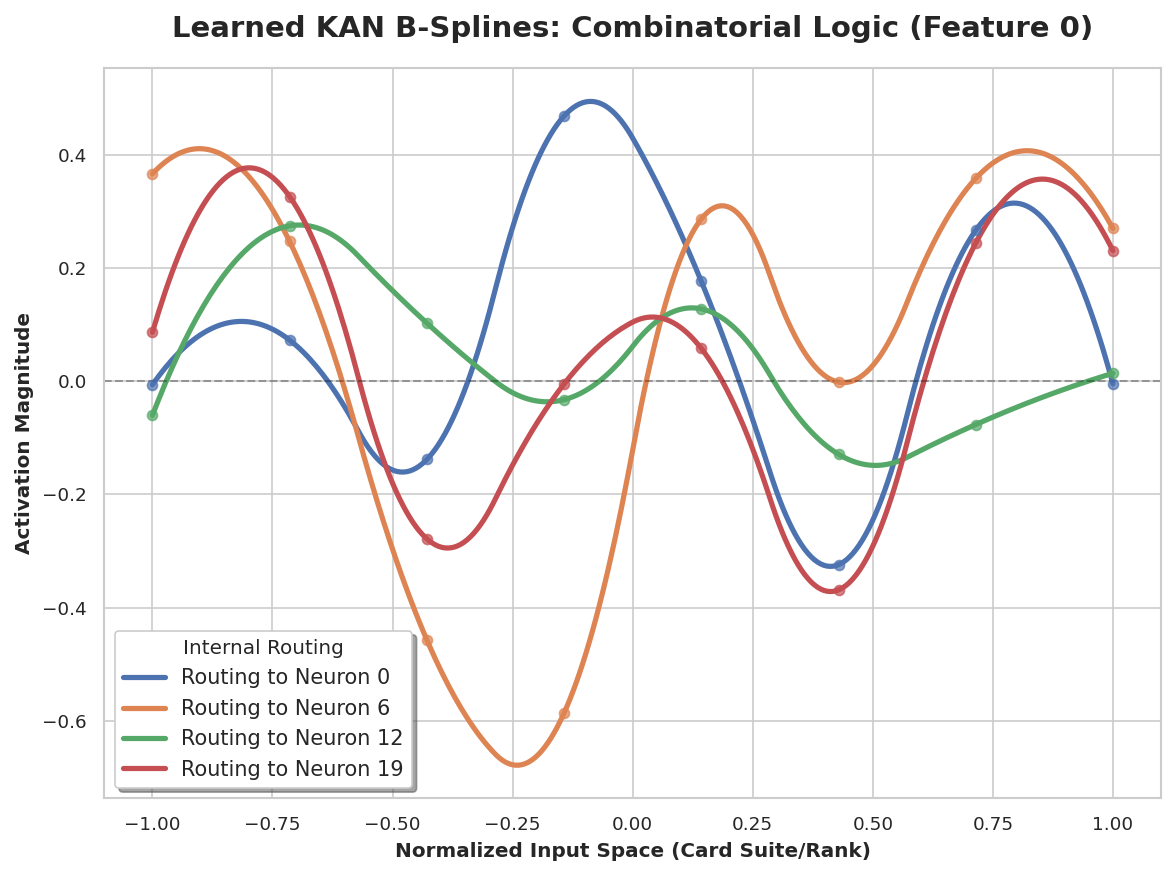

In [8]:
KAN_ZIP_PATH = f'{MODELS_DIR}/04_kan_param_matched_cosine_lr_25k.zip'
TEMP_EXTRACT_DIR = './tmp_kan_model_poker'

if os.path.exists(KAN_ZIP_PATH):
    with zipfile.ZipFile(KAN_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(TEMP_EXTRACT_DIR)

    state_dict = torch.load(f'{TEMP_EXTRACT_DIR}/network.pt', map_location='cpu', weights_only=True)

    # target the first KAN Layer
    target_layer_name = 'tabnet.encoder.initial_splitter.shared.shared_layers.0.spline_weight'
    spline_weights = state_dict[target_layer_name].numpy()

    print(f"Extracted B-Spline Tensor Shape: {spline_weights.shape}")
    print(f"Output Neurons: {spline_weights.shape[0]} | Input Features: {spline_weights.shape[1]} | Control Points: {spline_weights.shape[2]}\n")

    input_feature_idx = 0
    max_neuron = spline_weights.shape[0] - 1
    target_neurons = [0, max_neuron//3, (max_neuron//3)*2, max_neuron]

    plt.figure(figsize=(8, 6))

    for neuron_idx in target_neurons:
        control_points = spline_weights[neuron_idx, input_feature_idx, :]
        x_grid = np.linspace(-1, 1, len(control_points))

        spl = make_interp_spline(x_grid, control_points, k=2)
        x_smooth = np.linspace(x_grid.min(), x_grid.max(), 300)
        y_smooth = spl(x_smooth)

        plt.plot(x_smooth, y_smooth, linewidth=2.5, label=f'Routing to Neuron {neuron_idx}')
        plt.scatter(x_grid, control_points, zorder=5, alpha=0.7)

    plt.title(f'Learned KAN B-Splines: Combinatorial Logic (Feature {input_feature_idx})', pad=15, fontweight='bold', fontsize=14)
    plt.xlabel('Normalized Input Space (Card Suite/Rank)', fontweight='bold')
    plt.ylabel('Activation Magnitude', fontweight='bold')
    plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.3)
    plt.legend(title="Internal Routing", frameon=True, shadow=True, fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/05_b_spline_control_polygons.png', dpi=300, bbox_inches='tight')
    plt.show()

    # cleanup
    shutil.rmtree(TEMP_EXTRACT_DIR)
else:
    print(f"Model zip not found at {KAN_ZIP_PATH}. Please ensure the model was saved correctly.")

### Global Feature Importance Allocation
During the initial training phase, the `compute_importance` flag was intentionally set to `False` to optimize training speed and minimize computational overhead. Because TabNet's feature importance is strictly data-dependent—calculated dynamically via instance-wise attention masks rather than static weights—the global importance arrays were not serialized with the model binaries.

To visualize the architectural routing efficiency, we must perfectly recreate the deterministic testing environment and pass `X_test` through the frozen models using the `.explain()` method.

##### **Part 1: Deterministic Environment Setup**
To ensure strict methodological parity, we must re-initialize the exact random seeds and computational determinism settings used during the training loops. This guarantees the PyTorch backend processes the data topology exactly as it did during the initial evaluations.

In [9]:
%%capture
# install TabNet fork which allows switching between vanilla TabNet and KAN-TabNet
!pip install git+https://github.com/chuo-v/tabnet.git@v1.0.1-kan

In [10]:
import random

seed = 11
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [11]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

##### **Part 2: Topographical Data Preparation**
With the deterministic environment locked, we fetch and split the dataset to isolate the exact `X_test` tensor that the models were evaluated against.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
import gc

url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-training-true.data'
url_test = 'https://archive.ics.uci.edu/ml/machine-learning-databases/poker/poker-hand-testing.data'

df_train = pd.read_csv(url_train, header=None)
df_test = pd.read_csv(url_test, header=None)

# 0-index the categorical features for PyTorch embedding layers
X_train_full = df_train.iloc[:, :-1].values - 1
y_train_full = df_train.iloc[:, -1].values.astype(int)

X_test = df_test.iloc[:, :-1].values - 1
y_test = df_test.iloc[:, -1].values.astype(int)

# remove the permutation invariance trap that cripples standard MLPs on this dataset
def sort_poker_hands(X):
    # reshape from (N, 10) to (N, 5, 2) to lock each Suit with its Rank
    X_pairs = X.reshape(-1, 5, 2)

    # get the indices that sort each hand based on the Rank (index 1 of the pair)
    sort_indices = np.argsort(X_pairs[:, :, 1], axis=1)

    # apply the sort to both Suit and Rank simultaneously
    row_indices = np.arange(X.shape[0])[:, np.newaxis]
    X_sorted_pairs = X_pairs[row_indices, sort_indices]

    # flatten back to the standard (N, 10) TabNet input format
    return X_sorted_pairs.reshape(-1, 10)

print("Sorting hands to remove permutation invariance...")
X_train_full = sort_poker_hands(X_train_full)
X_test = sort_poker_hands(X_test)
print("Sorting complete.")

Sorting hands to remove permutation invariance...
Sorting complete.


##### **Part 3: Attention Extraction and Visualization**
We load the pre-trained, parameter-matched models and push `X_test` through an inference pass using the `.explain()` method. By averaging the resulting data-dependent instance masks, we successfully map the global feature importance allocation.

Loading models and extracting attention masks...
Calculating attention dynamics...
Plotting heatmap...


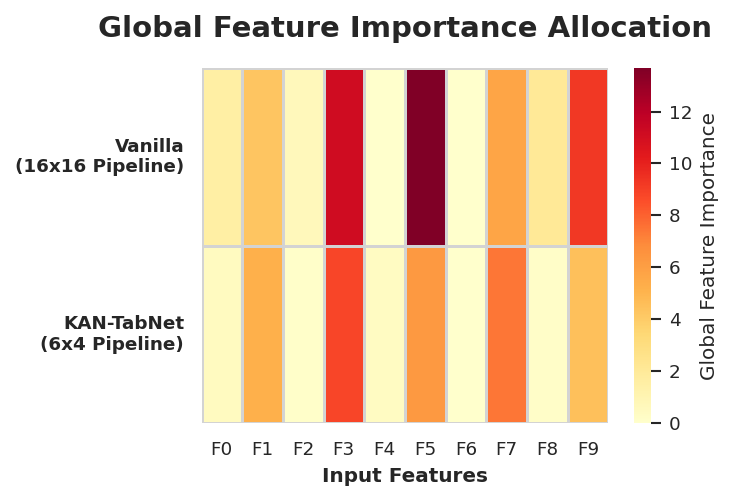

In [13]:
print("Loading models and extracting attention masks...")

# initialize classifiers and load saved models
clf_vanilla = TabNetClassifier()
clf_kan = TabNetClassifier()
clf_vanilla.load_model(f'{MODELS_DIR}/03_vanilla_baseline_cosine_lr_26k.zip')
clf_kan.load_model(f'{MODELS_DIR}/04_kan_param_matched_cosine_lr_25k.zip')

# extract interpretability masks
print("Calculating attention dynamics...")
explain_matrix_vanilla, _ = clf_vanilla.explain(X_test)
explain_matrix_kan, _ = clf_kan.explain(X_test)

vanilla_imp = explain_matrix_vanilla.mean(axis=0)
kan_imp = explain_matrix_kan.mean(axis=0)

# generate visualization
print("Plotting heatmap...")
importance_matrix = np.vstack([vanilla_imp, kan_imp])

plt.figure(figsize=(5, 3.5))
ax = sns.heatmap(
    importance_matrix,
    cmap="YlOrRd",
    cbar_kws={'label': 'Global Feature Importance'},
    yticklabels=['Vanilla\n(16x16 Pipeline)', 'KAN-TabNet\n(6x4 Pipeline)'],
    xticklabels=[f"F{i}" for i in range(10)],
    linewidths=0.5,
    linecolor='lightgray'
)

plt.title('Global Feature Importance Allocation', pad=15, fontweight='bold', fontsize=14)
plt.xlabel('Input Features', fontweight='bold')
plt.yticks(rotation=0, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()